In [180]:
# 1) importando libs
import pandas as pd
import seaborn as sns
import numpy as np
import pickle
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from matplotlib import pyplot as plt

In [181]:
# 2) criando df para fazer o ETL
df = pd.read_csv("bancobox.csv")
df

,idade,renda_mensal,tempo_emprego,dividas_total,limite_cartao,historico_credito,num_cartoes_credito,num_emprestimos,atraso_pagamento,possui_imovel,possui_veiculo,cargo_atual,risco_credito
0,50,4145.83,1.4,5798,13957.29,1,1,1,0,Não,Não,Analista de TI,Médio
1,40,14080.13,0.9,39607,57549.72,1,0,2,0,Não,Não,Enfermeiro,Alto
2,59,7550.31,21.0,7865,20694.49,3,4,0,0,Não,Sim,Advogado,Médio
3,27,2390.01,5.6,1340,10593.18,17,5,3,0,Sim,Não,Analista de TI,Baixo
4,39,17135.27,20.3,45245,77949.94,1,3,2,0,Sim,Não,Contador,Alto
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,70,17133.71,10.4,36559,53726.07,7,3,0,0,Não,Não,Professor,Alto
996,82,8224.03,14.3,7642,18414.90,12,3,0,0,Sim,Não,Médico,Baixo
997,88,3286.20,19.1,1472,16055.81,12,0,1,0,Sim,Sim,Professor,Baixo
998,86,14855.40,26.6,42765,28284.90,6,3,0,0,Sim,Sim,Contador,Alto


In [182]:
# vendo se há outliers
df.describe()

,idade,renda_mensal,tempo_emprego,dividas_total,limite_cartao,historico_credito,num_cartoes_credito,num_emprestimos,atraso_pagamento
count,1000.000000,951.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,54.714000,11084.092324,15.074200,16509.753000,31552.676700,9.950000,2.486000,1.479000,5.921000
std,20.721138,5246.045678,8.606815,13004.206382,20229.370451,6.129525,1.690758,1.123753,14.363114
min,19.000000,2039.990000,0.100000,0.000000,2374.180000,0.000000,0.000000,0.000000,0.000000
25%,37.000000,6563.215000,7.500000,6141.250000,15897.767500,5.000000,1.000000,0.000000,0.000000
50%,55.000000,11137.260000,14.900000,13289.000000,26743.405000,10.000000,2.000000,1.000000,0.000000
75%,73.000000,15712.695000,22.700000,24176.250000,43493.482500,15.000000,4.000000,2.000000,0.000000
max,90.000000,19977.490000,30.000000,58298.000000,97632.300000,20.000000,5.000000,3.000000,60.000000


<Figure size 1200x800 with 0 Axes>

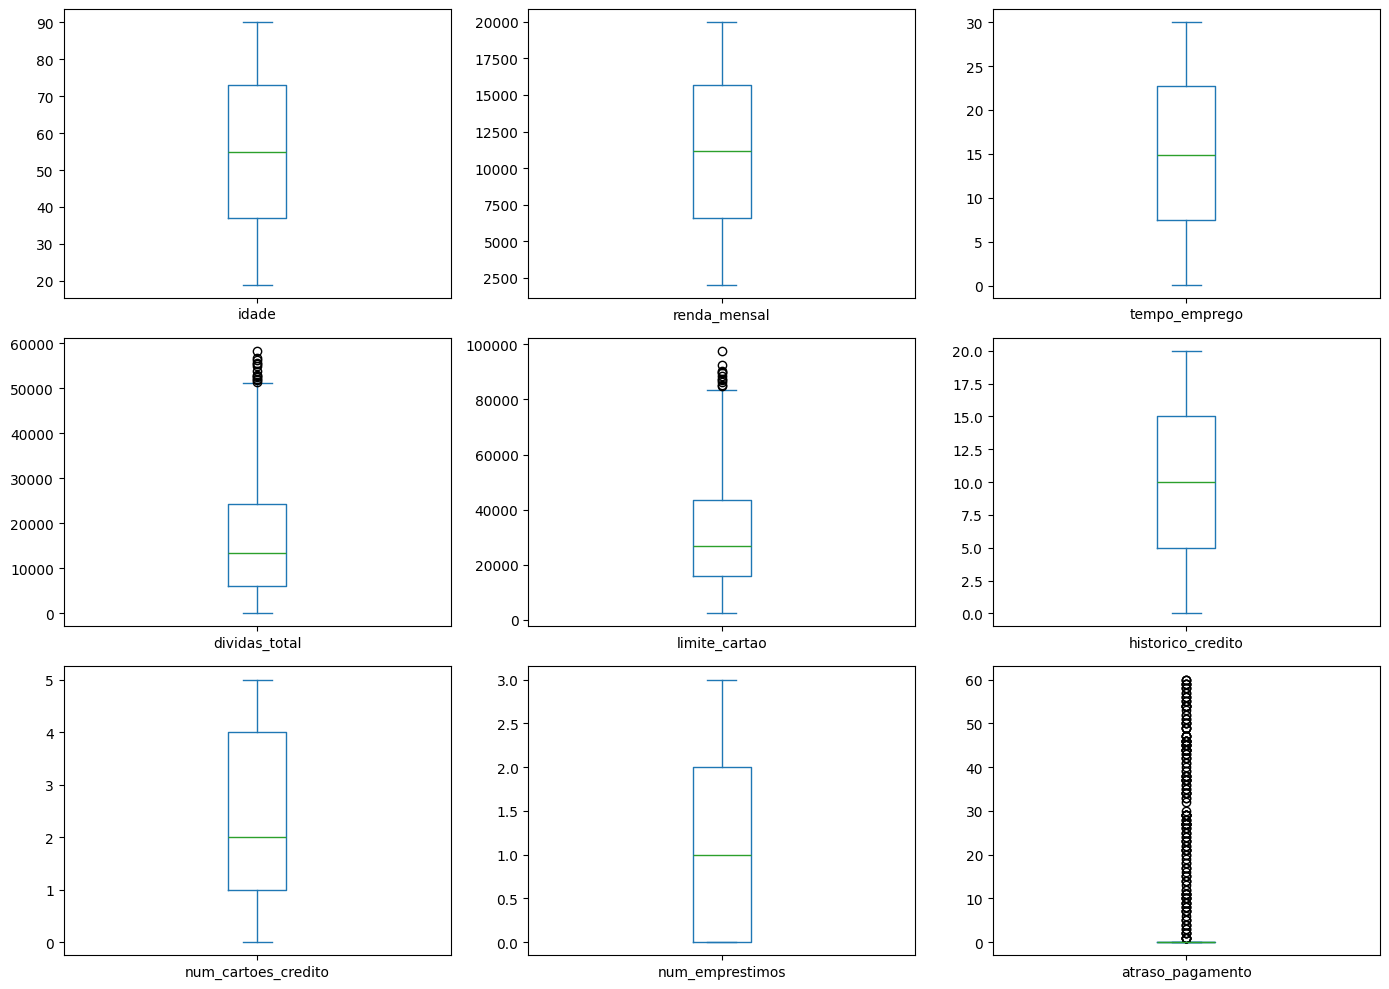

In [183]:
# cada caixinha mostra a mediana, os quartis e os pontos fora do bigode já são os outliers - mas não necessariamente absurdos
plt.figure(figsize=(12, 8))

df.select_dtypes(include='number').plot(
    kind='box', subplots=True, layout=(3, 3), figsize=(14, 10)
)
plt.tight_layout()
plt.show()

In [184]:
df['atraso_pagamento'].value_counts()

,count
atraso_pagamento,
0,808
27,8
29,8
46,7
44,7
54,6
1,6
37,6
45,6


In [185]:
# tratando a base de dados - verificando nulos
df.isnull().sum()

,0
idade,0
renda_mensal,49
tempo_emprego,0
dividas_total,0
limite_cartao,0
historico_credito,0
num_cartoes_credito,0
num_emprestimos,0
atraso_pagamento,0
possui_imovel,0


In [186]:
# tratando a base de dados
df['cargo_atual'].value_counts()

,count
cargo_atual,
Enfermeiro,117
Empreendedor,116
Analista de TI,112
Advogado,110
Contador,109
Designer,109
Médico,107
Professor,107
Engenheiro,97


In [187]:
# padronizando cargo_atual: lowercase, sem underscores, sem pontos, espaços normalizados
df['cargo_atual'] = (
    df['cargo_atual']
    .str.strip() # remove espaços nas bordas
    .str.lower() # tudo minúsculo para comparar
    .str.replace('_', ' ', regex=False) # Analista_de_TI → analista de ti
    .str.replace(r'\.+$', '', regex=True) # remove ponto no final:
    .str.replace(r'\s+', ' ', regex=True) # espaços duplos para simples
)

# mapeamento manual dos casos restantes
mapa_cargos = {
    'analista ti' : 'analista de ti',
    'analista_de_ti' : 'analista de ti',
    'eng' : 'engenheiro',
    'prof' : 'professor',
}
df['cargo_atual'] = df['cargo_atual'].replace(mapa_cargos)
df['cargo_atual'].value_counts()

,count
cargo_atual,
analista de ti,123
enfermeiro,117
empreendedor,116
advogado,110
professor,110
contador,109
designer,109
médico,107
engenheiro,99


In [188]:
# tratando a base de dados - removendo duplicatas
df.drop_duplicates(inplace=True)
df.shape

(1000, 13)

In [189]:
# tratando a base de dados - verificando tipos das colunas principais
df[["renda_mensal", "dividas_total"]].dtypes

,0
renda_mensal,float64
dividas_total,int64


In [190]:
# garantindo que renda_mensal e dividas_total são numéricos
df["renda_mensal"] = pd.to_numeric(df["renda_mensal"], errors="coerce")
df["dividas_total"] = pd.to_numeric(df["dividas_total"], errors="coerce")

# preenchendo possíveis valores nulos gerados com a mediana ou zero (neste caso usando a mediana)
df["renda_mensal"] = df["renda_mensal"].fillna(df["renda_mensal"].median())
df["dividas_total"] = df["dividas_total"].fillna(df["dividas_total"].median())

In [191]:
# criando nova coluna relação dívida/renda
df["relacao_divida_renda"] = df['dividas_total'] / df['renda_mensal']
df[['renda_mensal', 'dividas_total', 'relacao_divida_renda']].head()

,renda_mensal,dividas_total,relacao_divida_renda
0,4145.83,5798,1.398514
1,14080.13,39607,2.812971
2,7550.31,7865,1.041679
3,2390.01,1340,0.560667
4,17135.27,45245,2.640460


In [192]:
# tratando a base de dados - distribuição do risco_credito
df['risco_credito'].value_counts()

,count
risco_credito,
Alto,408
Médio,340
Baixo,252


In [193]:
# salvando dados tratados para análise de risco
df.to_csv("bancobox_tratado.csv", index=False)
print("salvo: bancobox_tratado.csv")

salvo: bancobox_tratado.csv


In [194]:
# NUMPY: média do histórico de crédito por categoria de risco
for risco in ["Baixo", "Médio", "Alto"]:
    media = np.mean(df[df["risco_credito"] == risco]["historico_credito"])
    print(f"Média histórico de crédito - Risco {risco}: {media:.2f}")

Média histórico de crédito - Risco Baixo: 10.02
Média histórico de crédito - Risco Médio: 10.19
Média histórico de crédito - Risco Alto: 9.70


In [195]:
# 3) pré-processamento das variáveis categóricas
le = LabelEncoder()
df["possui_imovel_enc"] = le.fit_transform(df["possui_imovel"])
df["possui_veiculo_enc"] = le.fit_transform(df["possui_veiculo"])
df["cargo_atual_enc"] = le.fit_transform(df["cargo_atual"])

print("Encoding concluído")

Encoding concluído


In [196]:
# 4) separando as variáveis
x = df[['idade', 'renda_mensal', 'tempo_emprego', 'dividas_total',
        'limite_cartao', 'historico_credito', 'num_cartoes_credito',
        'num_emprestimos', 'atraso_pagamento', 'possui_imovel_enc',
        'possui_veiculo_enc', 'relacao_divida_renda']]
y = df['risco_credito']

In [197]:
# 5) dividir os dados em treino e teste
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.2, random_state=42)

In [198]:
# 6) pré-processamento - apesar de que modelos em random forest não necessitam, mas o logistic regression SIM.
scaler = StandardScaler()
x_teste_original = x_teste.copy()  # guarda os valores originais para o gráfico
x_treino = scaler.fit_transform(x_treino)  # aprende a escala no treino e transforma
x_teste = scaler.transform(x_teste)  # use .fit_transform() só no treino. no teste, use apenas .transform(). assim você não vaza informação do teste para o treino.

In [199]:
# 7) criar modelo de logistic regression e random forest
modelo_lr = LogisticRegression(max_iter=1000)  # cria
modelo_lr.fit(x_treino, y_treino)  # treina

modelo = RandomForestClassifier(random_state=42, max_depth=5, n_estimators=100)  # cria
modelo.fit(x_treino, y_treino)  # treina

RandomForestClassifier(max_depth=5, random_state=42)

In [200]:
# 8) avaliação do modelo e previsão
previsao = modelo.predict(x_teste)
acuracia = accuracy_score(y_teste, previsao)
matriz = confusion_matrix(y_teste, previsao)

previsao_lr = modelo_lr.predict(x_teste)
acuracia_lr = accuracy_score(y_teste, previsao_lr)
matriz_lr = confusion_matrix(y_teste, previsao_lr)

In [201]:
# 9) printando
print(f"Acurácia (RF): {acuracia * 100:.2f}%")
print(f"Matriz de confusão (RF):\n{matriz}\n")

print(f"Acurácia (LR): {acuracia_lr * 100:.2f}%")
print(f"Matriz de confusão (LR):\n{matriz_lr}\n")

Acurácia (RF): 94.00%
Matriz de confusão (RF):
[[90  0  4]
 [ 0 39  2]
 [ 0  6 59]]

Acurácia (LR): 89.00%
Matriz de confusão (LR):
[[89  0  5]
 [ 0 38  3]
 [10  4 51]]



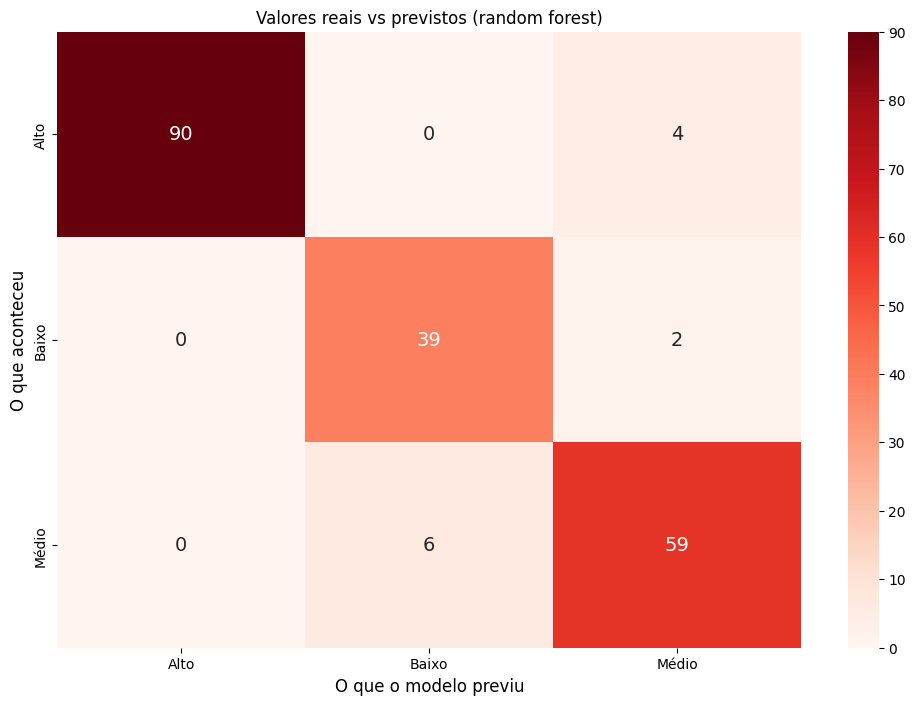

In [202]:
# 10) configurar o tamanho do gráfico
plt.figure(figsize=(12, 8))

# gerando a matriz de confusão (real x previsto) - Random Forest
labels = ['Alto', 'Baixo', 'Médio']
sns.heatmap(
    matriz, annot=True, fmt="d", cmap="Reds",
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"size": 14}  # aumenta tamanho da fonte dos números
)

# definindo titulo e label
plt.title("Valores reais vs previstos (random forest)", fontsize=12)
plt.ylabel("O que aconteceu", fontsize=12)
plt.xlabel("O que o modelo previu", fontsize=12)

# Mostrar o gráfico
plt.show()

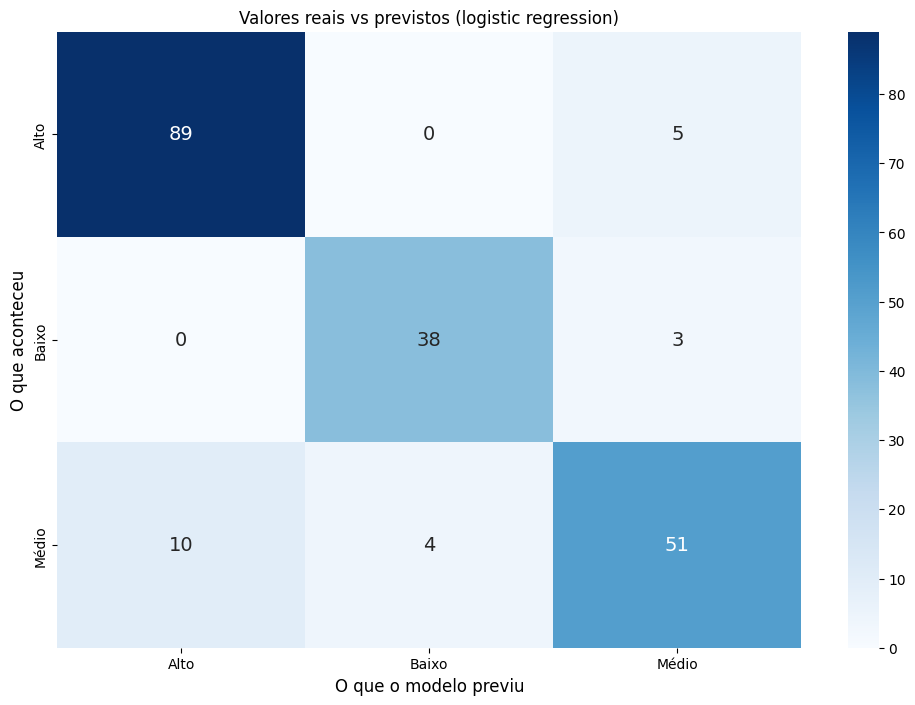

In [203]:
# 11) configurar o tamanho do gráfico
plt.figure(figsize=(12, 8))

# gerando a matriz de confusão (real x previsto) - Logistic Regression
labels = ['Alto', 'Baixo', 'Médio']
sns.heatmap(
    matriz_lr, annot=True, fmt="d", cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"size": 14}  # aumenta tamanho da fonte dos números
)

# definindo titulo e label
plt.title("Valores reais vs previstos (logistic regression)", fontsize=12)
plt.ylabel("O que aconteceu", fontsize=12)
plt.xlabel("O que o modelo previu", fontsize=12)

# Mostrar o gráfico
plt.show()

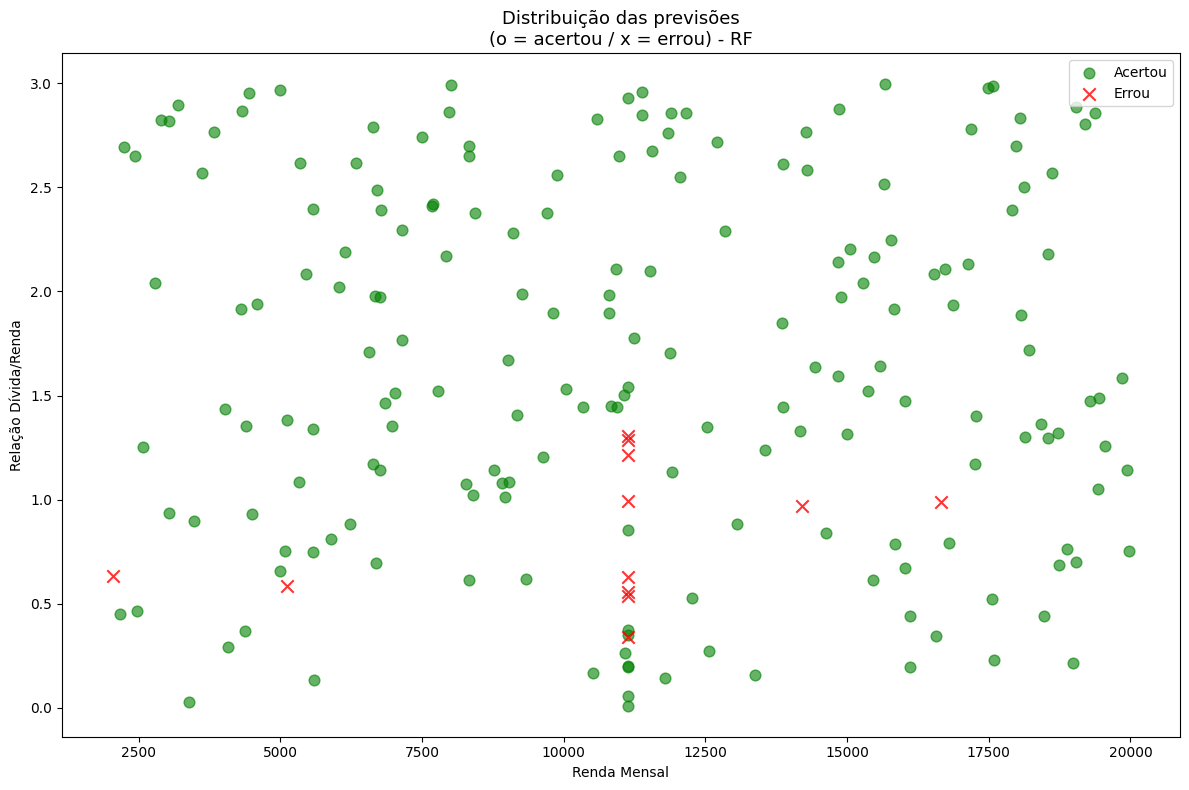

In [204]:
# 12) tamanho do gráfico
plt.figure(figsize=(12, 8))

# reconstruindo o dataframe com os valores originais de renda e relação dívida/renda
df_plot = x_teste_original.copy()
df_plot["Real"] = y_teste.values
df_plot["Previsto"] = previsao

# separando acertos e erros
acertos = df_plot[df_plot["Real"] == df_plot["Previsto"]]
erros = df_plot[df_plot["Real"] != df_plot["Previsto"]]

# plotando acertos em verde (o) e erros em vermelho (x)
acertos.plot.scatter(
    x="renda_mensal", y="relacao_divida_renda",
    c="green", marker="o", s=60,
    label="Acertou", ax=plt.gca(), alpha=0.6
)
erros.plot.scatter(
    x="renda_mensal", y="relacao_divida_renda",
    c="red", marker="x", s=80,
    label="Errou", ax=plt.gca(), alpha=0.8
)

# definindo título e labels
plt.title("Distribuição das previsões\n(o = acertou / x = errou) - RF", fontsize=13)
plt.xlabel("Renda Mensal")
plt.ylabel("Relação Dívida/Renda")
plt.legend()
plt.tight_layout()
plt.show()

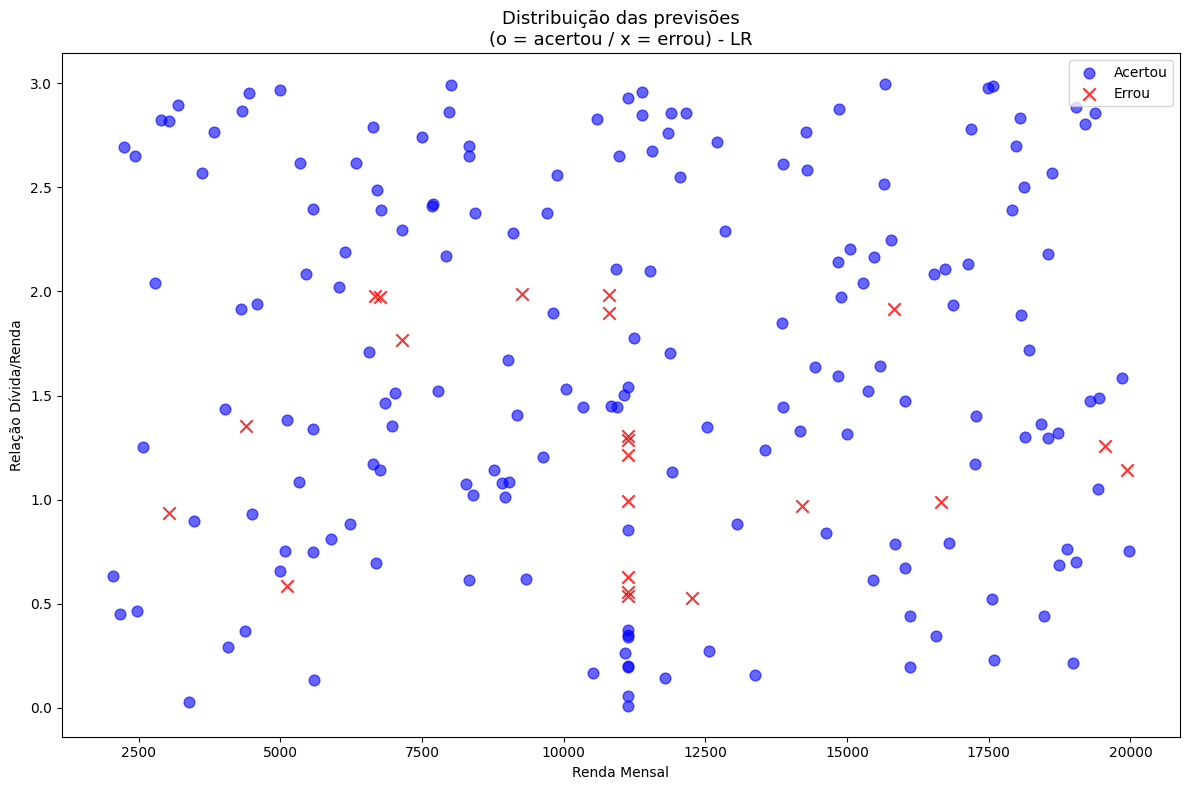

In [205]:
# 13) tamanho do gráfico
plt.figure(figsize=(12, 8))

# reconstruindo o dataframe com os valores originais de renda e relação dívida/renda
df_plot = x_teste_original.copy()
df_plot["Real"] = y_teste.values
df_plot["Previsto"] = previsao_lr

# separando acertos e erros
acertos = df_plot[df_plot["Real"] == df_plot["Previsto"]]
erros = df_plot[df_plot["Real"] != df_plot["Previsto"]]

# plotando acertos em blue (o) e erros em vermelho (x)
acertos.plot.scatter(
    x="renda_mensal", y="relacao_divida_renda",
    c="blue", marker="o", s=60,
    label="Acertou", ax=plt.gca(), alpha=0.6
)
erros.plot.scatter(
    x="renda_mensal", y="relacao_divida_renda",
    c="red", marker="x", s=80,
    label="Errou", ax=plt.gca(), alpha=0.8
)

# definindo título e labels
plt.title("Distribuição das previsões\n(o = acertou / x = errou) - LR", fontsize=13)
plt.xlabel("Renda Mensal")
plt.ylabel("Relação Dívida/Renda")
plt.legend()
plt.tight_layout()
plt.show()

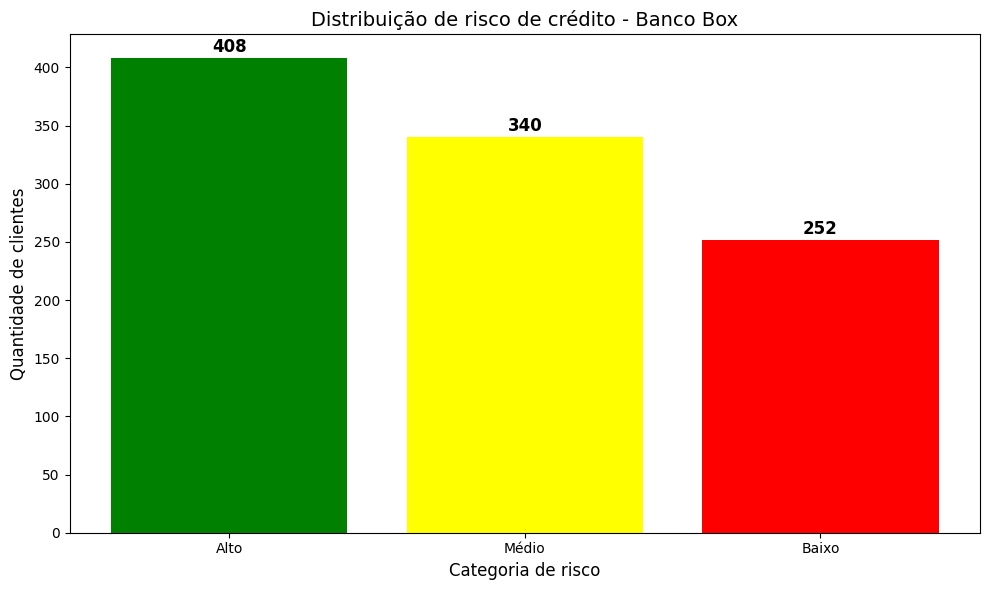

In [206]:
# MATPLOTLIB: gráfico de barras - distribuição de risco de crédito
plt.figure(figsize=(10, 6))

contagem = df['risco_credito'].value_counts()
cores = ['green', 'yellow', 'red']

plt.bar(contagem.index, contagem.values, color=cores)

plt.title("Distribuição de risco de crédito - Banco Box", fontsize=14)
plt.xlabel("Categoria de risco", fontsize=12)
plt.ylabel("Quantidade de clientes", fontsize=12)

for i, v in enumerate(contagem.values):
    plt.text(i, v + 5, str(v), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

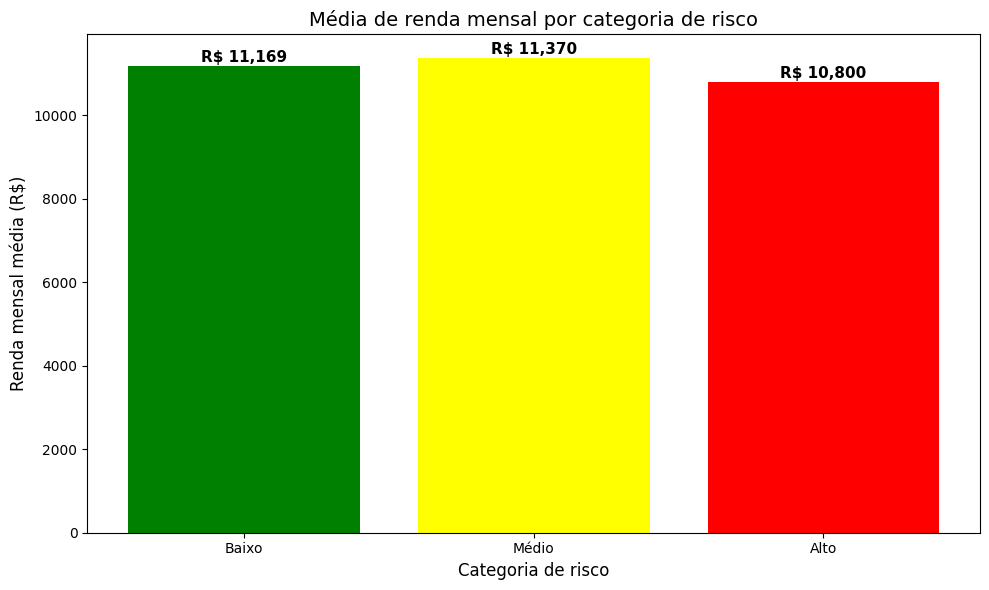

In [207]:
# MATPLOTLIB: gráfico de barras - média de renda mensal por risco
plt.figure(figsize=(10, 6))

media_renda = df.groupby('risco_credito')['renda_mensal'].mean().reindex(['Baixo', 'Médio', 'Alto'])
cores = ['green', 'yellow','red']

plt.bar(media_renda.index, media_renda.values, color=cores)

plt.title("Média de renda mensal por categoria de risco", fontsize=14)
plt.xlabel("Categoria de risco", fontsize=12)
plt.ylabel("Renda mensal média (R$)", fontsize=12)

for i, v in enumerate(media_renda.values):
    plt.text(i, v + 100, f"R$ {v:,.0f}", ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

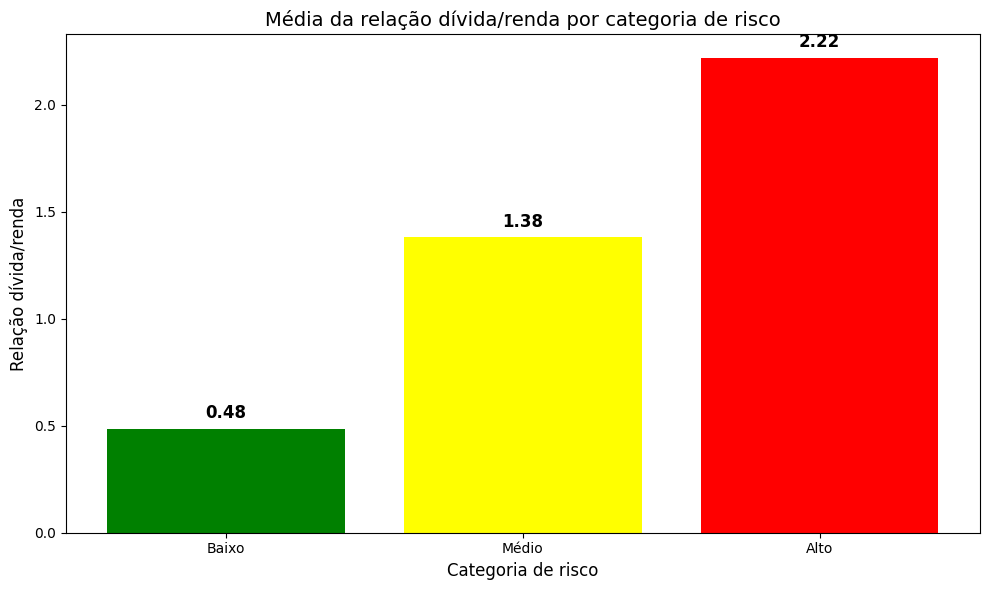

In [208]:
# MATPLOTLIB: gráfico de barras - média da relação dívida/renda por risco
plt.figure(figsize=(10, 6))

media_rel = df.groupby('risco_credito')['relacao_divida_renda'].mean().reindex(['Baixo', 'Médio', 'Alto'])
cores = ['green', 'yellow','red']

plt.bar(media_rel.index, media_rel.values, color=cores)

plt.title("Média da relação dívida/renda por categoria de risco", fontsize=14)
plt.xlabel("Categoria de risco", fontsize=12)
plt.ylabel("Relação dívida/renda", fontsize=12)

for i, v in enumerate(media_rel.values):
    plt.text(i, v + 0.05, f"{v:.2f}", ha='center', fontsize=12, fontweight='bold')
#enumerate(media_rel.values) — percorre os valores das barras junto com a posição (0, 1, 2). O i é a posição horizontal e v é o valor da barra

#plt.text(i, v + 0.05, ...) — desenha um texto na posição x=i, y=v+0.05. O + 0.05 é só um espacinho para o número não ficar colado no topo da barra

#ha='center' — centraliza o texto horizontalmente em cima da barra

plt.tight_layout()
plt.show()

In [209]:
# 14) salvar modelo e scaler juntos
with open("modelo_rf_bancobox.pkl", "wb") as f:
    pickle.dump(modelo, f)
with open("modelo_lr_bancobox.pkl", "wb") as f:
    pickle.dump(modelo_lr, f)
with open("scaler_bancobox.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("salvou modelos e scaler")

salvou modelos e scaler
